In [1]:
import pandas as pd
import nltk

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

df = pd.read_csv("/content/product_reviews.csv")

print(df.head())

  ReviewID  ProductID    UserID  Rating  \
0  REV2000  Product_E  User_114       4   
1  REV2001  Product_C  User_186       2   
2  REV2002  Product_E  User_101       3   
3  REV2003  Product_A  User_175       5   
4  REV2004  Product_C  User_158       1   

                              ReviewText  ReviewDate  
0       fantastic. wonderful experience.  2023-04-17  
1                   broke easily. awful.  2023-11-27  
2          met expectations. five stars.  2023-12-10  
3  very satisfied. wonderful experience.  2023-11-10  
4              worst purchase. one star.  2024-05-25  


In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [3]:
print(df)

    ReviewID  ProductID    UserID  Rating  \
0    REV2000  Product_E  User_114       4   
1    REV2001  Product_C  User_186       2   
2    REV2002  Product_E  User_101       3   
3    REV2003  Product_A  User_175       5   
4    REV2004  Product_C  User_158       1   
..       ...        ...       ...     ...   
995  REV2995  Product_D  User_133       3   
996  REV2996  Product_B  User_143       3   
997  REV2997  Product_C  User_185       3   
998  REV2998  Product_A  User_106       5   
999  REV2999  Product_D  User_105       1   

                                            ReviewText  ReviewDate  
0                     fantastic. wonderful experience.  2023-04-17  
1                                 broke easily. awful.  2023-11-27  
2                        met expectations. five stars.  2023-12-10  
3                very satisfied. wonderful experience.  2023-11-10  
4                            worst purchase. one star.  2024-05-25  
..                                           

In [4]:
stop_words = set(stopwords.words('english'))
print(stop_words)

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

{'any', 'been', 'out', 'having', "haven't", 'further', 'hers', 'aren', "won't", 'can', 'below', 'so', "i'll", 'those', 'did', 'who', "wouldn't", 'don', 's', 'her', 'is', "you'll", 'haven', 'through', 're', 'both', 'be', 'up', 'again', 'into', 'didn', "he's", "we'd", 'ourselves', 'down', "you've", 'as', 'being', 'doing', 'most', 'above', 'here', 'y', 'if', 'wouldn', 'shan', "we'll", 'have', 'ain', 'hadn', 'should', 'him', "it'd", 'herself', 'has', 'mightn', "it's", 'on', 'himself', "i'm", 'shouldn', 'the', 'after', 'between', 'm', "mustn't", 'my', "he'd", 'what', "isn't", 'do', 'am', 'own', 'only', 'against', "hasn't", 'once', "that'll", 'them', 'too', 'these', 'some', 't', 'such', 'we', 'doesn', 'itself', 'it', "doesn't", "she'd", 'does', "she'll", 'are', "he'll", 'couldn', 'how', "shouldn't", 'you', 'hasn', 'needn', 'wasn', 'when', "we've", 'that', 'over', 'more', 'while', 'o', 'in', 'its', 'his', 'no', 'whom', 'to', "i've", 'off', 've', 'our', 'their', 'yourself', "should've", 'was',

In [5]:
df['Lower_Text'] = df['ReviewText'].str.lower()

print(df[['ReviewText','Lower_Text']].head())

                              ReviewText  \
0       fantastic. wonderful experience.   
1                   broke easily. awful.   
2          met expectations. five stars.   
3  very satisfied. wonderful experience.   
4              worst purchase. one star.   

                              Lower_Text  
0       fantastic. wonderful experience.  
1                   broke easily. awful.  
2          met expectations. five stars.  
3  very satisfied. wonderful experience.  
4              worst purchase. one star.  


In [6]:
df['Word_Tokens'] = df['Lower_Text'].apply(word_tokenize)

print(df[['Lower_Text','Word_Tokens']].head())

                              Lower_Text  \
0       fantastic. wonderful experience.   
1                   broke easily. awful.   
2          met expectations. five stars.   
3  very satisfied. wonderful experience.   
4              worst purchase. one star.   

                                      Word_Tokens  
0        [fantastic, ., wonderful, experience, .]  
1                    [broke, easily, ., awful, .]  
2          [met, expectations, ., five, stars, .]  
3  [very, satisfied, ., wonderful, experience, .]  
4              [worst, purchase, ., one, star, .]  


In [7]:
def remove_stopwords(tokens):
    filtered_tokens = [
        word for word in tokens
        if word.lower() not in stop_words
    ]
    return filtered_tokens

df['Filtered_Tokens'] = df['Word_Tokens'].apply(remove_stopwords)

print(df[['Word_Tokens','Filtered_Tokens']].head())

                                      Word_Tokens  \
0        [fantastic, ., wonderful, experience, .]   
1                    [broke, easily, ., awful, .]   
2          [met, expectations, ., five, stars, .]   
3  [very, satisfied, ., wonderful, experience, .]   
4              [worst, purchase, ., one, star, .]   

                            Filtered_Tokens  
0  [fantastic, ., wonderful, experience, .]  
1              [broke, easily, ., awful, .]  
2    [met, expectations, ., five, stars, .]  
3  [satisfied, ., wonderful, experience, .]  
4        [worst, purchase, ., one, star, .]  


In [8]:
def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]

df['Stemmed_Tokens'] = df['Filtered_Tokens'].apply(stem_text)

print(df[['Filtered_Tokens','Stemmed_Tokens']].head(10))

                                     Filtered_Tokens  \
0           [fantastic, ., wonderful, experience, .]   
1                       [broke, easily, ., awful, .]   
2             [met, expectations, ., five, stars, .]   
3           [satisfied, ., wonderful, experience, .]   
4                 [worst, purchase, ., one, star, .]   
5               [pros, cons, ., works, perfectly, .]   
6       [highly, recommend, ., amazing, features, .]   
7                [waste, money, ., poor, quality, .]   
8  [love, product, ., highly, recommend, ., nothi...   
9             [poor, quality, ., worst, purchase, .]   

                                      Stemmed_Tokens  
0                    [fantast, ., wonder, experi, .]  
1                          [broke, easili, ., aw, .]  
2                    [met, expect, ., five, star, .]  
3                    [satisfi, ., wonder, experi, .]  
4                  [worst, purchas, ., one, star, .]  
5                  [pro, con, ., work, perfectli, .] 

In [9]:
def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['Lemmatized_Tokens'] = df['Filtered_Tokens'].apply(lemmatize_text)

print(df[['Stemmed_Tokens','Lemmatized_Tokens']].head(10))

                                      Stemmed_Tokens  \
0                    [fantast, ., wonder, experi, .]   
1                          [broke, easili, ., aw, .]   
2                    [met, expect, ., five, star, .]   
3                    [satisfi, ., wonder, experi, .]   
4                  [worst, purchas, ., one, star, .]   
5                  [pro, con, ., work, perfectli, .]   
6            [highli, recommend, ., amaz, featur, .]   
7                 [wast, money, ., poor, qualiti, .]   
8  [love, product, ., highli, recommend, ., noth,...   
9              [poor, qualiti, ., worst, purchas, .]   

                                   Lemmatized_Tokens  
0           [fantastic, ., wonderful, experience, .]  
1                       [broke, easily, ., awful, .]  
2               [met, expectation, ., five, star, .]  
3           [satisfied, ., wonderful, experience, .]  
4                 [worst, purchase, ., one, star, .]  
5                  [pro, con, ., work, perfectly, .] 

In [10]:
def process_text(text):

    text = str(text).lower()

    word_tokens = word_tokenize(text)

    filtered_tokens = [
        word for word in word_tokens
        if word.lower() not in stop_words
    ]

    stemmed_tokens = [
        stemmer.stem(word)
        for word in filtered_tokens
    ]

    lemmatized_tokens = [
        lemmatizer.lemmatize(word)
        for word in filtered_tokens
    ]

    return {
        "Original_Text": text,
        "Word_Tokens": word_tokens,
        "Filtered_Tokens": filtered_tokens,
        "Stemmed_Tokens": stemmed_tokens,
        "Lemmatized_Tokens": lemmatized_tokens
    }

results = df['ReviewText'].apply(process_text)

processed_df = pd.DataFrame(results.tolist())

print(processed_df.head())

                           Original_Text  \
0       fantastic. wonderful experience.   
1                   broke easily. awful.   
2          met expectations. five stars.   
3  very satisfied. wonderful experience.   
4              worst purchase. one star.   

                                      Word_Tokens  \
0        [fantastic, ., wonderful, experience, .]   
1                    [broke, easily, ., awful, .]   
2          [met, expectations, ., five, stars, .]   
3  [very, satisfied, ., wonderful, experience, .]   
4              [worst, purchase, ., one, star, .]   

                            Filtered_Tokens  \
0  [fantastic, ., wonderful, experience, .]   
1              [broke, easily, ., awful, .]   
2    [met, expectations, ., five, stars, .]   
3  [satisfied, ., wonderful, experience, .]   
4        [worst, purchase, ., one, star, .]   

                      Stemmed_Tokens                         Lemmatized_Tokens  
0    [fantast, ., wonder, experi, .]  [fantastic, .,

In [11]:
processed_file_path = "processed_product_reviews.csv"

processed_df.to_csv(
    processed_file_path,
    index=False
)

print(f"Processed data saved to {processed_file_path}")

Processed data saved to processed_product_reviews.csv


In [12]:
from sklearn.feature_extraction.text import CountVectorizer

text_data = processed_df['Original_Text']

vectorizer = CountVectorizer()

bow_matrix = vectorizer.fit_transform(text_data)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print("Vocabulary:")
print(vectorizer.vocabulary_)

print("\nFeature Names:")
print(vectorizer.get_feature_names_out())

print("\nShape:")
print(bow_matrix.shape)

print("\nBoW Matrix:")
print(bow_df.head())

Vocabulary:
{'fantastic': 25, 'wonderful': 67, 'experience': 24, 'broke': 9, 'easily': 17, 'awful': 4, 'met': 34, 'expectations': 22, 'five': 27, 'stars': 57, 'very': 64, 'satisfied': 52, 'worst': 70, 'purchase': 49, 'one': 43, 'star': 56, 'some': 54, 'pros': 48, 'and': 1, 'cons': 10, 'works': 69, 'perfectly': 44, 'highly': 31, 'recommend': 51, 'amazing': 0, 'features': 26, 'waste': 66, 'of': 41, 'money': 36, 'poor': 45, 'quality': 50, 'love': 33, 'this': 60, 'product': 47, 'nothing': 40, 'special': 55, 'customer': 12, 'service': 53, 'was': 65, 'bad': 5, 'best': 7, 'ever': 19, 'does': 16, 'not': 39, 'work': 68, 'decent': 13, 'for': 28, 'the': 59, 'price': 46, 'exceeded': 20, 'easy': 18, 'to': 61, 'use': 62, 'as': 2, 'expected': 23, 'difficult': 14, 'neither': 37, 'good': 29, 'nor': 38, 'great': 30, 'value': 63, 'would': 71, 'it': 32, 'okay': 42, 'terrible': 58, 'could': 11, 'be': 6, 'better': 8, 'excellent': 21, 'average': 3, 'missing': 35, 'disappointed': 15}

Feature Names:
['amazing

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(text_data)

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

print("Vocabulary:")
print(tfidf_vectorizer.vocabulary_)

print("\nShape:")
print(tfidf_matrix.shape)

print("\nTF-IDF Matrix:")
print(tfidf_df.head())

Vocabulary:
{'fantastic': 25, 'wonderful': 67, 'experience': 24, 'broke': 9, 'easily': 17, 'awful': 4, 'met': 34, 'expectations': 22, 'five': 27, 'stars': 57, 'very': 64, 'satisfied': 52, 'worst': 70, 'purchase': 49, 'one': 43, 'star': 56, 'some': 54, 'pros': 48, 'and': 1, 'cons': 10, 'works': 69, 'perfectly': 44, 'highly': 31, 'recommend': 51, 'amazing': 0, 'features': 26, 'waste': 66, 'of': 41, 'money': 36, 'poor': 45, 'quality': 50, 'love': 33, 'this': 60, 'product': 47, 'nothing': 40, 'special': 55, 'customer': 12, 'service': 53, 'was': 65, 'bad': 5, 'best': 7, 'ever': 19, 'does': 16, 'not': 39, 'work': 68, 'decent': 13, 'for': 28, 'the': 59, 'price': 46, 'exceeded': 20, 'easy': 18, 'to': 61, 'use': 62, 'as': 2, 'expected': 23, 'difficult': 14, 'neither': 37, 'good': 29, 'nor': 38, 'great': 30, 'value': 63, 'would': 71, 'it': 32, 'okay': 42, 'terrible': 58, 'could': 11, 'be': 6, 'better': 8, 'excellent': 21, 'average': 3, 'missing': 35, 'disappointed': 15}

Shape:
(1000, 72)

TF-ID

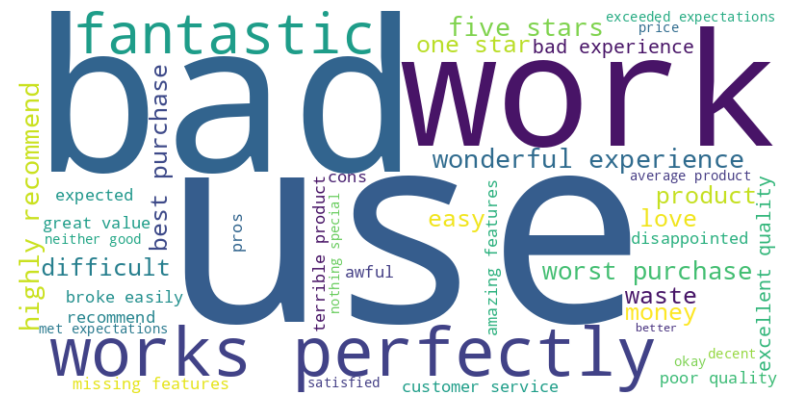

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_data = " ".join(
    processed_df['Original_Text'].dropna()
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [15]:
comparison_df = processed_df[
    [
        'Original_Text',
        'Stemmed_Tokens',
        'Lemmatized_Tokens'
    ]
]

print(comparison_df.head(10))

comparison_df.to_csv(
    "stemming_vs_lemmatization.csv",
    index=False
)

                                       Original_Text  \
0                   fantastic. wonderful experience.   
1                               broke easily. awful.   
2                      met expectations. five stars.   
3              very satisfied. wonderful experience.   
4                          worst purchase. one star.   
5               some pros and cons. works perfectly.   
6                highly recommend. amazing features.   
7                      waste of money. poor quality.   
8  love this product. highly recommend. nothing s...   
9                      poor quality. worst purchase.   

                                      Stemmed_Tokens  \
0                    [fantast, ., wonder, experi, .]   
1                          [broke, easili, ., aw, .]   
2                    [met, expect, ., five, star, .]   
3                    [satisfi, ., wonder, experi, .]   
4                  [worst, purchas, ., one, star, .]   
5                  [pro, con, ., work, perfectl